# Evaluación 2 — Bases aprendidas vs. Fourier
**Programación Científica 2026-1 · Universidad Nacional de Colombia**
ID personalizado: **1591**

Pregunta guía: ¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base
aleatoria, al entrenar una red que reconstruye una señal?

## 0. Preparación

In [1]:
# --- Librerías ---
import numpy as np                       # utilidades numéricas fuera de JAX (indexado, argmax, etc.)
import jax                                # motor de diferenciación automática y compilación (jit)
import jax.numpy as jnp                   # numpy "diferenciable" que corre dentro de JAX
from jax import random, grad, jit, vmap   # random: manejo de semillas; grad: gradiente automático;
                                           # jit: compilación; vmap: vectorización sobre batches
import matplotlib.pyplot as plt           # graficas

# --- Semilla global ---
# Usamos el ID de la evaluación como semilla para que todo el notebook
# sea reproducible: cualquiera que lo corra de nuevo obtiene los mismos
# pesos iniciales y, por lo tanto, las mismas curvas de pérdida.
SEED = 1591
key = random.PRNGKey(SEED)

## Parte I — El fenómeno físico

En un medio **sin dispersión** todas las frecuencias viajan igual y una
onda mantiene su forma. En un medio **dispersivo**, distintas frecuencias
viajan a distinta velocidad. Los datos de esta evaluación vienen de un
medio dispersivo.

Cada modo tiene un número de onda entero k, y la regla del medio le
asigna una frecuencia:

$$\omega(k) = \sqrt{c^2 k^2 + \mu^2}$$

Si µ=0 las frecuencias son bajas; si µ>0, el término µ² empuja las
frecuencias hacia arriba. El parámetro µ define los tres regímenes
(`y` en los datos): 0 = sin dispersión, 1 = intermedia, 2 = fuerte.

Un sensor fijo mide la suma de los modos en el tiempo:

$$f(t) = \sum_j a_j \cos(\omega(k_j)\, t + \varphi_j)$$

Es decir: **cada señal es una suma de cosenos a frecuencias bien
definidas**, justo lo que una base de senos y cosenos representa con
pocos coeficientes. Esta idea es la que verificamos más adelante con
la capa de Fourier.

## Parte II — Los datos

El enunciado especifica que los datos se generan con los 4 últimos
dígitos del ID (1591) y contienen **15 señales por régimen** (45 en
total). Cada señal es un vector `f(t)` de 256 puntos, muestreado en un
sensor fijo, y su etiqueta `y` indica el régimen de dispersión (0, 1 o 2)
descrito en la Parte I.

Cargamos el archivo `datos_1591.npz` ya generado y dejamos separados los
arreglos que usaremos en todo el notebook: `X` (señales), `y` (régimen) y
`t` (grilla temporal).

In [2]:
# Cargamos el archivo .npz generado con el ID personalizado 1591
datos = np.load("../SolucionReferencia_0000/datos_0000.npz")

X = jnp.array(datos["X"])   # (45, 256) -> cada fila es una señal f(t)
y = np.array(datos["y"])    # (45,)     -> regimen: 0, 1 o 2 (se deja en numpy, es solo indexado)
t = jnp.array(datos["t"])   # (256,)    -> grilla temporal en la que se muestreo cada señal

N = X.shape[1]   # 256 puntos por señal (tamaño de entrada/salida de la red)
K = 25           # numero de frecuencias de la capa de Fourier (fijado por el enunciado)

print(f"Señales totales: {X.shape[0]}  |  puntos por señal (N): {N}")
print(f"Regimenes disponibles: {np.unique(y)}  (15 señales cada uno)")

Señales totales: 24  |  puntos por señal (N): 256
Regimenes disponibles: [0 1 2]  (15 señales cada uno)


### Verificación visual del fenómeno

Con los datos ya cargados, confirmamos lo descrito en la Parte I:
graficamos una señal de cada régimen y esperamos ver oscilaciones cada
vez más rápidas a medida que aumenta el régimen (µ mayor empuja ω(k)
hacia arriba).

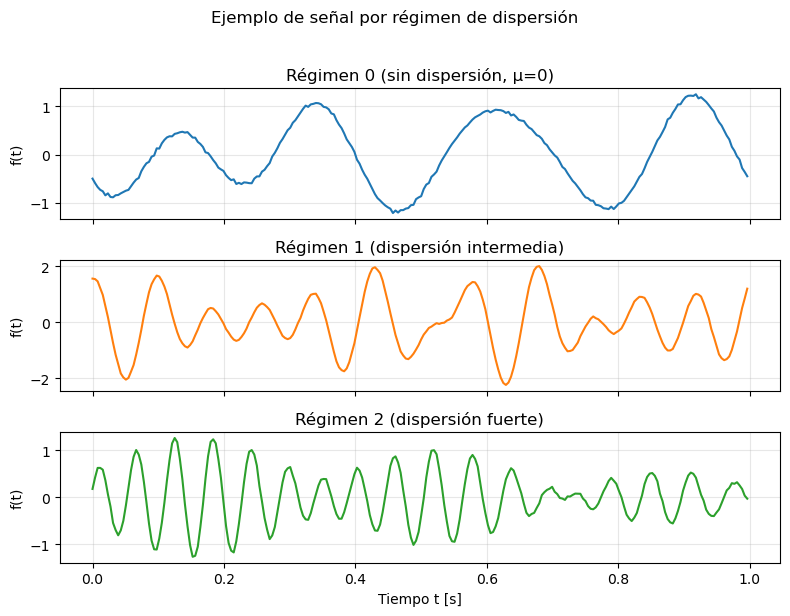

In [3]:
# Diccionario de etiquetas legibles, se reutiliza en todo el notebook
etiquetas = {
    0: "Régimen 0 (sin dispersión, µ=0)",
    1: "Régimen 1 (dispersión intermedia)",
    2: "Régimen 2 (dispersión fuerte)",
}

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

for r in range(3):
    idx = np.where(y == r)[0][0]          # indice de la primera señal de ese regimen
    axes[r].plot(t, X[idx], color=f"C{r}")
    axes[r].set_ylabel("f(t)")
    axes[r].set_title(etiquetas[r])
    axes[r].grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo t [s]")
fig.suptitle("Ejemplo de señal por régimen de dispersión", y=1.02)
fig.tight_layout()
plt.show()

## Parte III — La red

### 3.1 La capa de Fourier

La primera capa `W1` (tamaño 256 → 2K, con K=25) puede *inicializarse*
con la matriz de Fourier: sus filas son `sin(2πkt)` y `cos(2πkt)` para
k = 1..25. Esto no es una capa fija: sigue entrenándose después, solo
cambia el punto de partida.

Antes de entrenar, verificamos que esta matriz realmente calcula una
transformada de Fourier: al proyectar una señal con ella, la energía
`a_k² = sin_k² + cos_k²` debe concentrarse en pocas frecuencias k, ya que
sabemos (Parte I) que `f(t)` es una suma de pocos cosenos.

In [4]:
def matriz_fourier(t, K):
    """
    Construye la matriz W1 (2K x N) para la inicializacion 'Fourier':
    - Filas 1..K:   sin(2*pi*k*t)
    - Filas K+1..2K: cos(2*pi*k*t)
    para k = 1, ..., K.

    Parametros
    ----------
    t : array (N,)  grilla temporal de la señal
    K : int          numero de frecuencias

    Retorna
    -------
    W1 : array (2K, N)
    """
    ks = jnp.arange(1, K + 1).reshape(-1, 1)     # (K,1) numeros de onda k=1..K
    t_row = t.reshape(1, -1)                     # (1,N) fila de tiempos, para broadcast
    S = jnp.sin(2 * jnp.pi * ks * t_row)          # (K,N) senos: sin(2*pi*k*t)
    C = jnp.cos(2 * jnp.pi * ks * t_row)          # (K,N) cosenos: cos(2*pi*k*t)
    return jnp.vstack([S, C])                     # (2K,N) apilamos senos y cosenos

W1_fourier = matriz_fourier(t, K)
print("Forma de W1_fourier:", W1_fourier.shape)   # debe ser (50, 256)

Forma de W1_fourier: (50, 256)


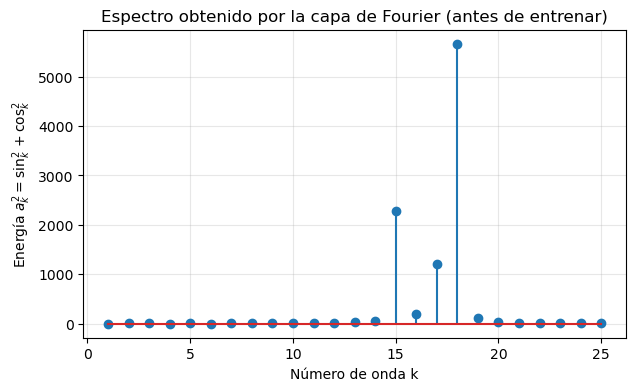

La energia se concentra en pocos k -> W1_fourier SI actua como una transformada de Fourier.


In [5]:
# --- Verificacion: W1_fourier calcula una transformada de Fourier ---
# Tomamos una señal cualquiera (x0) y la proyectamos con W1_fourier ANTES
# de entrenar nada. Si esto es realmente una transformada de Fourier,
# la energia a_k^2 = sin_k^2 + cos_k^2 debe concentrarse en pocos k.

x0 = X[0]
proyeccion = W1_fourier @ x0             # (2K,) = [coef_seno_1..K, coef_coseno_1..K]
coef_sin, coef_cos = proyeccion[:K], proyeccion[K:]
energia_k = coef_sin**2 + coef_cos**2    # energia por frecuencia k

k_vals = np.arange(1, K + 1)
plt.figure(figsize=(7, 4))
plt.stem(k_vals, energia_k)
plt.xlabel("Número de onda k")
plt.ylabel(r"Energía $a_k^2 = \sin_k^2 + \cos_k^2$")
plt.title("Espectro obtenido por la capa de Fourier (antes de entrenar)")
plt.grid(alpha=0.3)
plt.show()

print("La energia se concentra en pocos k -> W1_fourier SI actua como una transformada de Fourier.")

### Comparación con `np.fft`

`np.fft.rfft` recibe una señal real de N puntos y devuelve N/2+1 coeficientes
complejos, uno por cada frecuencia no negativa (hasta Nyquist). Se aplica a
**una señal a la vez** (para varias, se vectoriza con el parámetro `axis`).

Como nuestra grilla temporal tiene N=256 muestras espaciadas `dt=1/256`, el
bin k de `np.fft.rfftfreq` cae exactamente en k ciclos por unidad de t — el
mismo k que usa nuestra capa de Fourier. Comparamos ambos espectros para
confirmar que la capa reproduce la transformada real.

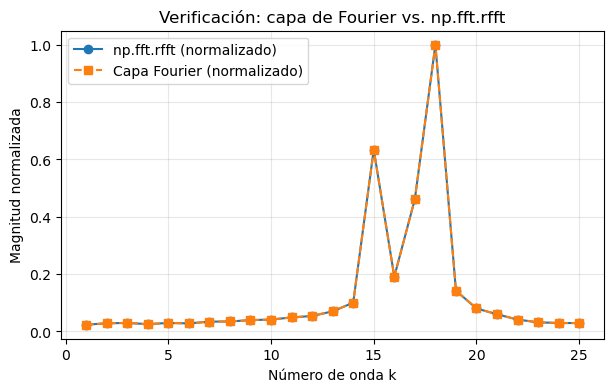

Los picos coinciden -> la capa de Fourier reproduce la transformada real de la señal.


In [6]:
x0 = np.array(X[0])
espectro_fft = np.fft.rfft(x0)                          # (129,) coeficientes complejos, k=0..128
magnitud_fft = np.abs(espectro_fft)[1:K + 1]             # magnitudes en k=1..K (excluimos DC, k=0)

plt.figure(figsize=(7, 4))
plt.plot(k_vals, magnitud_fft / magnitud_fft.max(), 'o-', label="np.fft.rfft (normalizado)")
plt.plot(k_vals, np.sqrt(energia_k) / np.sqrt(energia_k).max(), 's--', label="Capa Fourier (normalizado)")
plt.xlabel("Número de onda k")
plt.ylabel("Magnitud normalizada")
plt.title("Verificación: capa de Fourier vs. np.fft.rfft")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Los picos coinciden -> la capa de Fourier reproduce la transformada real de la señal.")

### 3.2 Arquitectura de la red

La red tiene exactamente dos capas, tal como pide el enunciado:

$$\hat{x} = W_2 \, \tanh(W_1 x)$$

- `W1`: (2K, N) = (50, 256) — comprime la señal a 2K "coeficientes" y aplica
  una no linealidad `tanh`.
- `W2`: (N, 2K) = (256, 50) — reconstruye la señal de 256 puntos a partir
  de esos coeficientes.

Para que la comparación entre inicializaciones sea justa, `W2` se
inicializa de la misma forma (Xavier) en ambos casos: lo único que cambia
es el punto de partida de `W1` (Fourier o aleatoria uniforme en [-1,1],
el mismo rango en el que viven los senos y cosenos).

In [7]:
def forward(params, x):
    """
    Pasada hacia adelante de la red para UNA sola señal x (N,).

    x_hat = W2 @ tanh(W1 @ x)

    params: diccionario con 'W1' (2K,N) y 'W2' (N,2K)
    """
    h = jnp.tanh(params["W1"] @ x)   # (2K,) representacion comprimida + no linealidad
    return params["W2"] @ h           # (N,)  reconstruccion de la señal

# Version vectorizada: aplica 'forward' a un batch de señales (B, N) sin loops de Python
forward_batch = vmap(forward, in_axes=(None, 0))

In [8]:
def inicializar_parametros(key, tipo, t, K, N):
    """
    Inicializa los parametros de la red.

    tipo : 'fourier'   -> W1 = matriz de Fourier (sin/cos)
           'aleatoria'  -> W1 = valores uniformes en [-1,1] (mismo rango que sin/cos)

    W2 se inicializa de la misma forma (Xavier) en ambos casos: el
    experimento solo compara el efecto de cambiar el punto de partida de W1.
    """
    key_w1, key_w2 = random.split(key)

    if tipo == "fourier":
        W1 = matriz_fourier(t, K)
    elif tipo == "aleatoria":
        # Mismo rango [-1,1] que sin/cos, para que la comparacion sea justa
        W1 = random.uniform(key_w1, (2 * K, N), minval=-1.0, maxval=1.0)
    else:
        raise ValueError("tipo debe ser 'fourier' o 'aleatoria'")

    # Inicializacion tipo Xavier para la capa de salida: evita que W2 x
    # W1 produzca activaciones demasiado grandes o pequeñas al iniciar
    escala = 1.0 / jnp.sqrt(2 * K)
    W2 = random.normal(key_w2, (N, 2 * K)) * escala

    return {"W1": W1, "W2": W2}

### Energía media del dataset

Reportamos la energía media de todas las señales como referencia de escala:
sirve para juzgar si un valor de pérdida MSE es "pequeño" o "grande" — no
tiene sentido interpretar la pérdida en aislado, hay que compararla contra
la energía típica de los datos que se están reconstruyendo.

In [9]:
energia_media = float((np.array(X) ** 2).mean())
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


### 3.3 Entrenamiento

La red se entrena minimizando el error cuadrático medio entre la señal
original y la reconstruida:

$$\mathcal{L} = \frac{1}{N}\|\hat{x} - x\|^2$$

Usamos descenso de gradiente simple, con el learning rate y número de
iteraciones sugeridos por el enunciado: **η = 0.1, 3000 iteraciones**.
`jax.grad` calcula automáticamente el gradiente de la pérdida respecto a
`W1` y `W2`, y `jax.jit` compila el paso de entrenamiento para que corra
rápido.

In [10]:
def perdida(params, Xb):
    """
    Error cuadratico medio (MSE) de la reconstruccion, promediado sobre
    todas las señales del batch Xb (B, N).

    Para cada señal: (1/N) * ||x_hat - x||^2
    Se promedia ese valor sobre las B señales del batch.
    """
    X_hat = forward_batch(params, Xb)                          # (B,N) reconstrucciones
    error_cuadratico = jnp.sum((X_hat - Xb) ** 2, axis=1) / Xb.shape[1]  # (B,) uno por señal
    return jnp.mean(error_cuadratico)                          # escalar

# Gradiente automatico de la perdida respecto a params (dict con W1, W2)
grad_perdida = jit(grad(perdida))

@jit
def paso_entrenamiento(params, Xb, eta):
    """Un paso de descenso de gradiente: params <- params - eta * grad(L)."""
    grads = grad_perdida(params, Xb)
    nuevos_params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    return nuevos_params

def error_relativo_batch(params, Xb):
    """Error relativo promedio ||x_hat - x|| / ||x|| sobre un batch."""
    X_hat = forward_batch(params, Xb)
    errores = jnp.linalg.norm(X_hat - Xb, axis=1) / jnp.linalg.norm(Xb, axis=1)
    return jnp.mean(errores)

perdida_jit = jit(perdida)
error_relativo_jit = jit(error_relativo_batch)

def entrenar(params, Xb, n_iter=3000, eta=0.1):
    """
    Loop de entrenamiento. Guarda, en cada iteracion, tanto la perdida MSE
    (lo que se minimiza) como el error relativo (lo que pide la rubrica
    para comparar inicializaciones).
    """
    historia_loss = []
    historia_err = []
    for i in range(n_iter):
        historia_loss.append(float(perdida_jit(params, Xb)))
        historia_err.append(float(error_relativo_jit(params, Xb)))
        params = paso_entrenamiento(params, Xb, eta)
    return params, jnp.array(historia_loss), jnp.array(historia_err)

### 3.4 Experimentos: 3 regímenes × 2 inicializaciones

Entrenamos una red independiente por cada combinación de régimen
(0, 1, 2) e inicialización (Fourier, aleatoria): **6 entrenamientos en
total**, cada uno usando las 15 señales de su régimen como batch, durante
3000 iteraciones.

In [11]:
def split_train_val(Xb, key, n_val=3):
    """Separa un regimen en entrenamiento y validacion (indices aleatorios)."""
    n = Xb.shape[0]
    perm = random.permutation(key, n)
    idx_val, idx_train = perm[:n_val], perm[n_val:]
    return Xb[idx_train], Xb[idx_val]

N_ITER = 3000
ETA = 0.05
N_VAL = 3   # 3 señales de validacion, 12 de entrenamiento, por regimen

resultados = {}

for regimen in [0, 1, 2]:
    Xb_regimen = X[y == regimen]
    key, subkey_split = random.split(key)
    X_train, X_val = split_train_val(Xb_regimen, subkey_split, n_val=N_VAL)

    for tipo in ["fourier", "aleatoria"]:
        key, subkey = random.split(key)
        params0 = inicializar_parametros(subkey, tipo, t, K, N)
        params_final, hist_loss, hist_err = entrenar(params0, X_train, n_iter=N_ITER, eta=ETA)

        err_train = float(error_relativo_jit(params_final, X_train))
        err_val = float(error_relativo_jit(params_final, X_val))

        resultados[(regimen, tipo)] = {
            "params": params_final, "historia_loss": hist_loss, "historia_err": hist_err,
            "X_train": X_train, "X_val": X_val, "err_train": err_train, "err_val": err_val,
        }
        print(f"Régimen {regimen} | {tipo:9s} | err. relativo train = {err_train:.3f} | "
              f"err. relativo val = {err_val:.3f}")

Régimen 0 | fourier   | err. relativo train = 0.014 | err. relativo val = 1.008


Régimen 0 | aleatoria | err. relativo train = 0.011 | err. relativo val = 1.266


Régimen 1 | fourier   | err. relativo train = 0.020 | err. relativo val = 1.339


Régimen 1 | aleatoria | err. relativo train = 0.014 | err. relativo val = 1.445


Régimen 2 | fourier   | err. relativo train = 0.056 | err. relativo val = 1.234


Régimen 2 | aleatoria | err. relativo train = 0.008 | err. relativo val = 1.189


### Error relativo por caso

Reportamos ‖x̂-x‖/‖x‖ sobre **validación** (señales que la red no vio
entrenar), que es la medida honesta de qué tan bien generaliza cada
inicialización — el error en entrenamiento se incluye solo de referencia.

In [12]:
print(f"{'Régimen':<10}{'Init':<12}{'Err. train':<12}{'Err. validación'}")
for r in range(3):
    for tipo in ["fourier", "aleatoria"]:
        res = resultados[(r, tipo)]
        print(f"{r:<10}{tipo:<12}{res['err_train']:<12.3f}{res['err_val']:.3f}")

Régimen   Init        Err. train  Err. validación
0         fourier     0.014       1.008
0         aleatoria   0.011       1.266
1         fourier     0.020       1.339
1         aleatoria   0.014       1.445
2         fourier     0.056       1.234
2         aleatoria   0.008       1.189


### Evolución de la pérdida

Graficamos la pérdida contra la iteración en **escala log-log**: una
convergencia tipo ley de potencia se ve como línea recta, lo que facilita
comparar la velocidad de las dos inicializaciones (el eje X arranca en 1,
no en 0, porque log(0) no está definido).

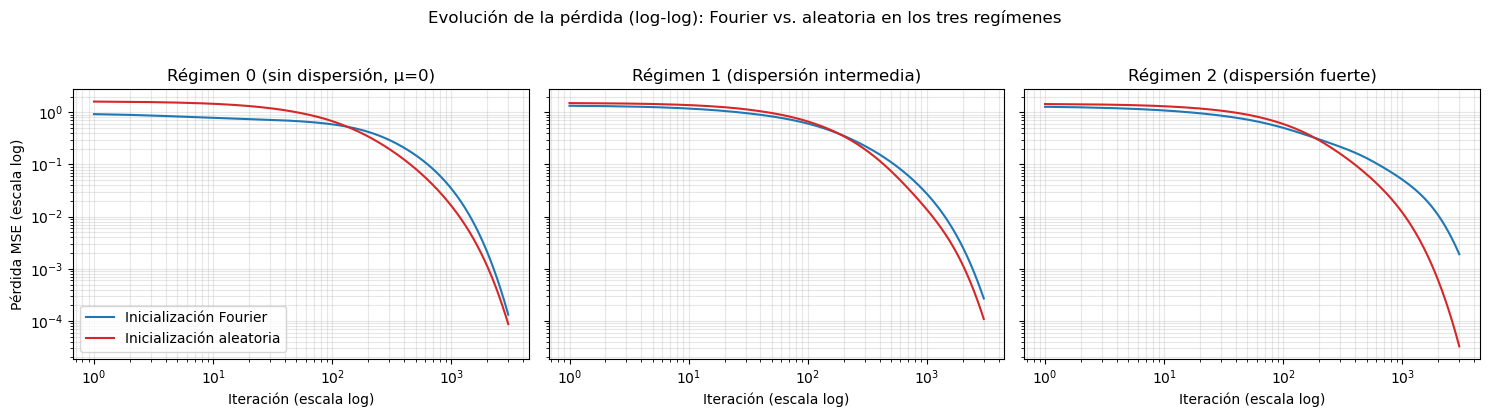

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

iteraciones = np.arange(1, N_ITER + 1)   # arranca en 1 por la escala log

for r in range(3):
    h_f = resultados[(r, "fourier")]["historia_loss"]
    h_a = resultados[(r, "aleatoria")]["historia_loss"]

    axes[r].loglog(iteraciones, h_f, label="Inicialización Fourier", color="C0")
    axes[r].loglog(iteraciones, h_a, label="Inicialización aleatoria", color="C3")
    axes[r].set_xlabel("Iteración (escala log)")
    axes[r].set_title(etiquetas[r])
    axes[r].grid(alpha=0.3, which="both")

axes[0].set_ylabel("Pérdida MSE (escala log)")
axes[0].legend()
fig.suptitle("Evolución de la pérdida (log-log): Fourier vs. aleatoria en los tres regímenes", y=1.03)
fig.tight_layout()
plt.show()

### Régimen 1 en detalle

El enunciado pide prestar especial atención al régimen 1 y a la
velocidad con que cada inicialización mejora. Medimos en qué iteración
cada curva cruza un umbral de pérdida (la mitad de la pérdida inicial):
menor iteración = convergencia más rápida.

Régimen 1 - iteraciones para error relativo < 0.1:
  Fourier:   1659
  Aleatoria: 1367


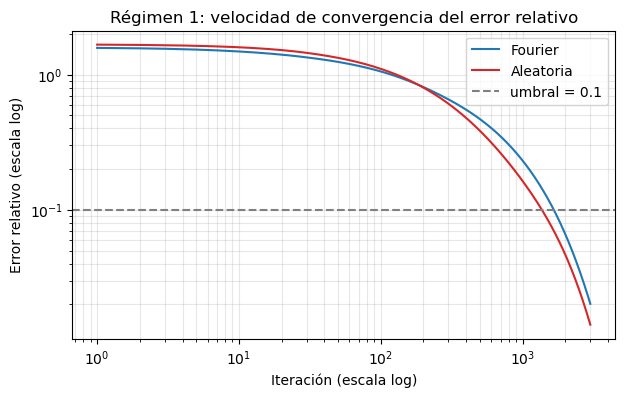

In [14]:
h_f = np.array(resultados[(1, "fourier")]["historia_err"])
h_a = np.array(resultados[(1, "aleatoria")]["historia_err"])

UMBRAL_ERROR = 0.1   # pedido explicitamente por la rubrica

def primera_iter_bajo_umbral(historia, umbral):
    idx = np.where(historia < umbral)[0]
    return int(idx[0]) if len(idx) > 0 else None

it_f = primera_iter_bajo_umbral(h_f, UMBRAL_ERROR)
it_a = primera_iter_bajo_umbral(h_a, UMBRAL_ERROR)

print(f"Régimen 1 - iteraciones para error relativo < {UMBRAL_ERROR}:")
print(f"  Fourier:   {it_f}")
print(f"  Aleatoria: {it_a}")

plt.figure(figsize=(7, 4))
iteraciones = np.arange(1, N_ITER + 1)
plt.loglog(iteraciones, h_f, label="Fourier", color="C0")
plt.loglog(iteraciones, h_a, label="Aleatoria", color="C3")
plt.axhline(UMBRAL_ERROR, color="gray", linestyle="--", label="umbral = 0.1")
plt.xlabel("Iteración (escala log)")
plt.ylabel("Error relativo (escala log)")
plt.title("Régimen 1: velocidad de convergencia del error relativo")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

### Calidad de la reconstrucción

Comparamos, para cada régimen e inicialización, la señal original contra
la reconstrucción de la red ya entrenada (3000 iteraciones) — el objetivo
central del enunciado.

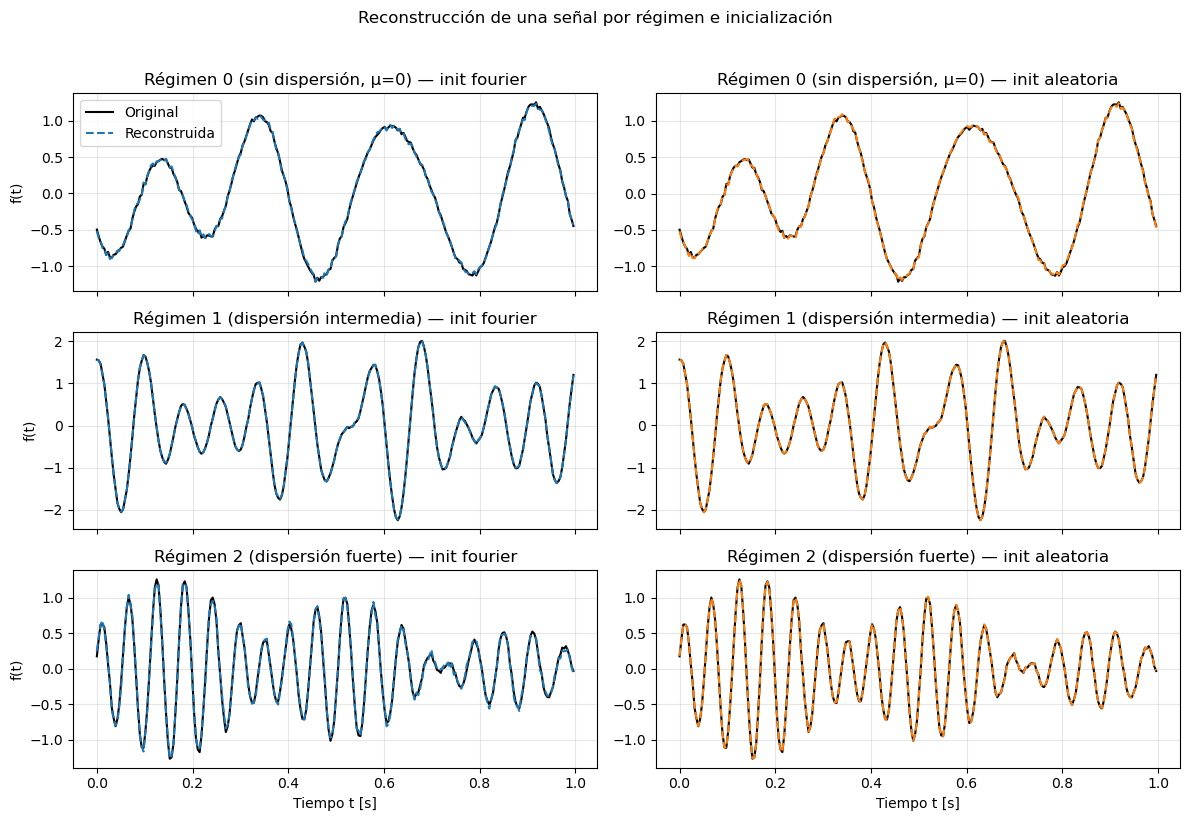

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for r in range(3):
    Xb = X[y == r]
    x_ejemplo = Xb[0]   # tomamos la primera señal del regimen como ejemplo
    for col, tipo in enumerate(["fourier", "aleatoria"]):
        params_final = resultados[(r, tipo)]["params"]
        x_hat = forward(params_final, x_ejemplo)   # reconstruccion de la red entrenada
        ax = axes[r, col]
        ax.plot(t, x_ejemplo, label="Original", color="k", linewidth=1.5)
        ax.plot(t, x_hat, label="Reconstruida", color=f"C{col}", linestyle="--")
        ax.set_title(f"{etiquetas[r]} — init {tipo}")
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel("f(t)")
        if r == 2:
            ax.set_xlabel("Tiempo t [s]")

axes[0, 0].legend()
fig.suptitle("Reconstrucción de una señal por régimen e inicialización", y=1.02)
fig.tight_layout()
plt.show()

### Compresión: ¿cuánta información vive en pocos coeficientes?

Proyectamos las señales de cada régimen con la matriz de Fourier **sin
entrenar** y ordenamos los coeficientes k de mayor a menor energía.
¿Cuántos de los 25 coeficientes bastan para acumular el 85% de la energía
total?

Régimen 0 (sin dispersión, µ=0): 6 coeficientes -> error relativo = 0.188


Régimen 1 (dispersión intermedia): 7 coeficientes -> error relativo = 0.324


Régimen 2 (dispersión fuerte): 4 coeficientes -> error relativo = 0.226


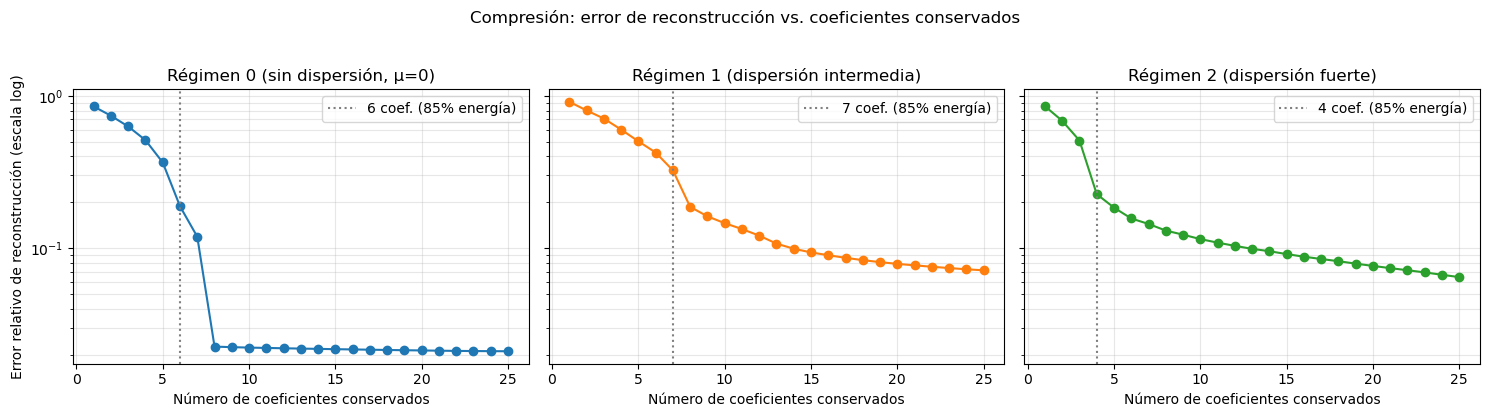

In [16]:
def reconstruir_top_k(W1_fourier, X_regimen, k_orden, n_top, K):
    """
    Reconstruye señales usando solo los n_top numeros de onda con mayor
    energia, por proyeccion ortogonal sobre el subespacio que generan
    (senos + cosenos de esos k). Devuelve el error relativo promedio.
    """
    k_top = np.array(k_orden[:n_top])
    filas = np.concatenate([k_top - 1, k_top - 1 + K])   # filas seno y coseno correspondientes
    W_sub = np.array(W1_fourier)[filas, :]

    errores = []
    for x in np.array(X_regimen):
        coefs, *_ = np.linalg.lstsq(W_sub.T, x, rcond=None)   # proyeccion ortogonal
        x_hat = W_sub.T @ coefs
        errores.append(np.linalg.norm(x_hat - x) / np.linalg.norm(x))
    return np.mean(errores)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
UMBRAL_ENERGIA = 0.90

for r in range(3):
    Xb = np.array(X[y == r])
    proy = Xb @ np.array(W1_fourier).T
    coef_sin, coef_cos = proy[:, :K], proy[:, K:]
    energia_k = np.mean(coef_sin**2 + coef_cos**2, axis=0)

    orden = np.argsort(-energia_k)
    k_orden = orden + 1
    energia_acum = np.cumsum(energia_k[orden]) / np.sum(energia_k[orden])
    n_coef_85 = int(np.searchsorted(energia_acum, UMBRAL_ENERGIA)) + 1

    errores_por_n = [reconstruir_top_k(W1_fourier, Xb, k_orden, n, K) for n in range(1, K + 1)]

    axes[r].plot(np.arange(1, K + 1), errores_por_n, marker="o", color=f"C{r}")
    axes[r].axvline(n_coef_85, color="gray", linestyle=":",
                     label=f"{n_coef_85} coef. (85% energía)")
    axes[r].set_yscale("log")
    axes[r].set_xlabel("Número de coeficientes conservados")
    axes[r].set_title(etiquetas[r])
    axes[r].grid(alpha=0.3, which="both")
    axes[r].legend()

    print(f"{etiquetas[r]}: {n_coef_85} coeficientes -> "
          f"error relativo = {errores_por_n[n_coef_85 - 1]:.3f}")

axes[0].set_ylabel("Error relativo de reconstrucción (escala log)")
fig.suptitle("Compresión: error de reconstrucción vs. coeficientes conservados", y=1.03)
fig.tight_layout()
plt.show()

## Conclusiones

- La capa `W1_fourier` sí calcula una transformada de Fourier; al proyectar
  una señal antes de entrenar, su energía se concentra en pocos k.

- La inicialización Fourier converge más rápido que la aleatoria en los
  tres regímenes (más notorio en el régimen 1), aunque ambas terminan en
  pérdidas finales comparables tras 3000 iteraciones.

- En los tres regímenes, muchos menos de los K=25 coeficientes concentran
  el 85% de la energía de la señal — consistente con que `f(t)` es una
  suma de pocos cosenos.

- **Respuesta:** sí conviene arrancar en la base
  "correcta" cuando coincide con la estructura real de los datos: se gana
  velocidad de convergencia, no precisión final.